# SmoothQuant W8A8 与 ZeroQuant：kernel 友好量化（教学 Demo）

> **PTQ 系列 06 / 13** · 对应博客篇目：**《SmoothQuant 与 ZeroQuant：激活平滑与逐代进化的 W8A8 量化》**
> （同仓库 `technology/quantization/ptq/06_smoothquant_zeroquant.md`；本目录 `run.py` 为其配套实验脚本）

**一段话原理**：W8A8 的难点从来不在权重，而在激活——LLM 激活里存在少数「常驻 outlier 通道」，会把 per-tensor / per-token 量化的 scale 直接拉爆，让正常数值只剩个位数比特的有效精度。SmoothQuant 注意到对任意逐通道缩放向量 $s$ 恒有 $XW = (X\,\mathrm{diag}(s)^{-1})(\mathrm{diag}(s)\,W)$，于是按迁移公式

$$s_j = \frac{\max|X_{:,j}|^{\alpha}}{\max|W_{j,:}|^{\,1-\alpha}}$$

把激活的量化难度按比例 $\alpha$ 搬运给权重：权重侧有 per-channel scale 兜底、被放大也扛得住，激活侧 outlier 被削平、变得可量化，而输出在数学上分毫不变。ZeroQuant 走另一条路：不改分布，用 group-wise 权重量化加 token-wise 动态激活量化把粒度做细。本 demo 用纯 numpy 复现三件事——**迁移公式的有效性**、**α 扫描的 U 形「跷跷板」**、以及 **per-token 激活与 per-channel 权重的组合拳**。

## 第 0 步 · 环境与量化算子

**这步在做什么**：固定随机种子，实现对称 INT8 量化的几个基本算子——激活 per-token 动态量化（每行一个 scale）、权重 per-channel 静态量化（每输出列一个 scale），以及后面对照组要用的 per-tensor 与 group-wise 权重量化，最后组装出统一的 W8A8 前向。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0                          # 全程固定种子，结果可复现
rng = np.random.default_rng(SEED)
QMAX = 2**7 - 1                   # INT8 对称网格上界 127


def quant_per_token(X, bits=8):
    """对称 per-token 激活量化：每个 token（每行）一个动态 scale。"""
    qmax = 2 ** (bits - 1) - 1
    s = np.max(np.abs(X), axis=1, keepdims=True) / qmax
    s = np.where(s == 0, 1.0, s)
    return np.clip(np.round(X / s), -qmax, qmax) * s


def quant_per_channel(W, bits=8):
    """对称 per-channel 权重量化：每个输出通道（每列）一个静态 scale。"""
    qmax = 2 ** (bits - 1) - 1
    s = np.max(np.abs(W), axis=0, keepdims=True) / qmax
    s = np.where(s == 0, 1.0, s)
    return np.clip(np.round(W / s), -qmax, qmax) * s


def quant_per_tensor(W, bits=8):
    """对称 per-tensor 权重量化：整张量一个 scale（最粗粒度对照）。"""
    qmax = 2 ** (bits - 1) - 1
    s = max(float(np.max(np.abs(W))), 1e-12) / qmax
    return np.clip(np.round(W / s), -qmax, qmax) * s


def quant_group_wise(W, g, bits=8):
    """group-wise 权重量化（ZeroQuant V1）：沿输出维每 g 列共享一个 scale。"""
    qmax = 2 ** (bits - 1) - 1
    d_in, d_out = W.shape
    assert d_out % g == 0
    Wr = W.reshape(d_in, d_out // g, g)
    s = np.max(np.abs(Wr), axis=2, keepdims=True) / qmax
    s = np.where(s == 0, 1.0, s)
    return (np.clip(np.round(Wr / s), -qmax, qmax) * s).reshape(d_in, d_out)


def w8a8_forward(X, W, s_vec=None, weight_mode="per-channel", group=64):
    """W8A8 线性层：可选传入平滑向量 s_vec；激活一律 per-token，权重粒度可选。"""
    Xp = X if s_vec is None else X / s_vec           # X' = X diag(s)^{-1}
    Wp = W if s_vec is None else W * s_vec[:, None]  # W' = diag(s) W
    Xq = quant_per_token(Xp)
    if weight_mode == "per-tensor":
        Wq = quant_per_tensor(Wp)
    elif weight_mode == "group-wise":
        Wq = quant_group_wise(Wp, group)
    else:
        Wq = quant_per_channel(Wp)
    return Xq @ Wq


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_err(a, b):
    return float(np.linalg.norm(a - b) / np.linalg.norm(b))


print("ready: numpy", np.__version__, "| SEED =", SEED, "| QMAX =", QMAX)

ready: numpy 2.1.1 | SEED = 0 | QMAX = 127


## 第 1 步 · 合成数据：重尾激活与高斯权重

**这步在做什么**：构造一个 toy 规模线性层（所有矩阵不超过 512×512）：激活 $X$ 大体服从 $\mathcal{N}(0, 0.3^2)$，但随机挑 12 个输入通道放大 20～80 倍，模拟 LLM 中「跨 token 稳定存在」的常驻 outlier；权重 $W$ 则是老实的高斯分布——权重本来就不闹事，闹事的总是激活。

In [2]:
T, D_IN, D_OUT = 512, 256, 512    # toy 规模：X 为 512x256，W 为 256x512
N_OUTLIER = 12                    # 常驻 outlier 通道数（约 4.7%）

X = rng.normal(0.0, 0.3, size=(T, D_IN))                        # 正常激活
outlier_ids = rng.choice(D_IN, N_OUTLIER, replace=False)
X[:, outlier_ids] *= rng.uniform(20.0, 80.0, size=N_OUTLIER)    # 幅值放大 20~80 倍
W = rng.normal(0.0, 0.04, size=(D_IN, D_OUT))                   # 高斯权重
Y_REF = X @ W                                                   # 全精度参考输出

col_max = np.max(np.abs(X), axis=0)
mag_ratio = float(col_max[outlier_ids].mean() / np.median(col_max))
print(f"X{X.shape}, W{W.shape}, outliers = {N_OUTLIER}/{D_IN} ({N_OUTLIER/D_IN:.1%})")
print(f"outlier channel mean|x| / median = {mag_ratio:.0f}x")

X(512, 256), W(256, 512), outliers = 12/256 (4.7%)
outlier channel mean|x| / median = 39x


## 第 2 步 · 误差评估基线：直接 W8A8 有多惨

**这步在做什么**：不做任何预处理直接跑 W8A8（per-token 激活 + per-channel 权重），看 outlier 如何「绑架」每个 token 的 scale，并统计正常数值还能分到多少有效位宽。

In [3]:
Y_NAIVE = w8a8_forward(X, W)                       # 不平滑的直接 W8A8
mse_naive = mse(Y_NAIVE, Y_REF)
rel_naive = rel_err(Y_NAIVE, Y_REF)

# 有效位宽：典型正常值（约 3 sigma = 0.9）在当前 token scale 下能分到的电平数
token_scale = np.max(np.abs(X), axis=1, keepdims=True) / QMAX
eff_bits_naive = float(np.mean(np.log2(2 * 0.9 / token_scale + 1)))

print(f"naive W8A8   MSE = {mse_naive:.3e}   rel err = {rel_naive:.2%}")
print(f"effective bits of normal values = {eff_bits_naive:.1f} / 8  (scale hijacked by outliers)")

naive W8A8   MSE = 2.009e-03   rel err = 2.52%
effective bits of normal values = 3.3 / 8  (scale hijacked by outliers)


## 第 3 步 · 方法核心：SmoothQuant 迁移公式

**这步在做什么**：实现 $s_j = \max|X_{:,j}|^{\alpha} / \max|W_{j,:}|^{1-\alpha}$，取论文默认 $\alpha = 0.5$ 做平滑后再量化；同时核验两件事——恒等式本身零误差（不量化时 $X'W'$ 与 $XW$ 严格相等，即平滑「免费」），以及平滑后正常值有效位宽的恢复幅度。

In [4]:
def smooth_scale(X, W, alpha):
    """迁移公式：s_j = max|X_j|^alpha / max|W_j|^(1-alpha)，j 为输入通道。"""
    amax_x = np.max(np.abs(X), axis=0)             # (D_IN,) 每输入通道激活幅值
    amax_w = np.max(np.abs(W), axis=1)             # (D_IN,) 每输入通道权重幅值
    return amax_x ** alpha / (amax_w ** (1 - alpha) + 1e-12)


ALPHA = 0.5                                        # 论文默认值 = 理论均衡点
S_HALF = smooth_scale(X, W, ALPHA)
Y_SMOOTH = w8a8_forward(X, W, s_vec=S_HALF)
mse_smooth = mse(Y_SMOOTH, Y_REF)
rel_smooth = rel_err(Y_SMOOTH, Y_REF)

# 核验 1：恒等式零误差——随便换个 alpha，不量化时输出也应严格相等
s_check = smooth_scale(X, W, 0.37)
identity_dev = float(np.max(np.abs((X / s_check) @ (W * s_check[:, None]) - Y_REF)))

# 核验 2：平滑后正常值的有效位宽恢复
s_sm = np.max(np.abs(X / S_HALF), axis=1, keepdims=True) / QMAX
eff_bits_smooth = float(np.mean(np.log2(2 * 0.9 / s_sm + 1)))

print(f"identity max|X'W' - XW| = {identity_dev:.2e}   (float precision => smoothing is free)")
print(f"smooth(alpha={ALPHA})   MSE = {mse_smooth:.3e}   rel err = {rel_smooth:.2%}")
print(f"MSE improvement = {mse_naive / mse_smooth:.1f}x ; "
      f"effective bits {eff_bits_naive:.1f} -> {eff_bits_smooth:.1f}")

identity max|X'W' - XW| = 2.66e-15   (float precision => smoothing is free)
smooth(alpha=0.5)   MSE = 1.835e-04   rel err = 0.76%
MSE improvement = 10.9x ; effective bits 3.3 -> 7.4


## 第 4 步 · 难度守恒：平滑只搬运、不消灭难度

**这步在做什么**：数值核验 $\max|X'_j| \cdot \max|W'_j| = \max|X_j| \cdot \max|W_j|$（每通道 range 乘积在平滑前后不变），并画出激活各通道幅值「削峰填谷」的前后对比——左图两条乘积曲线重合即守恒，右图可见 outlier 通道被削平、正常通道被轻微抬升。

per-channel range product: max rel deviation = 2.63e-16  (machine eps => conserved)


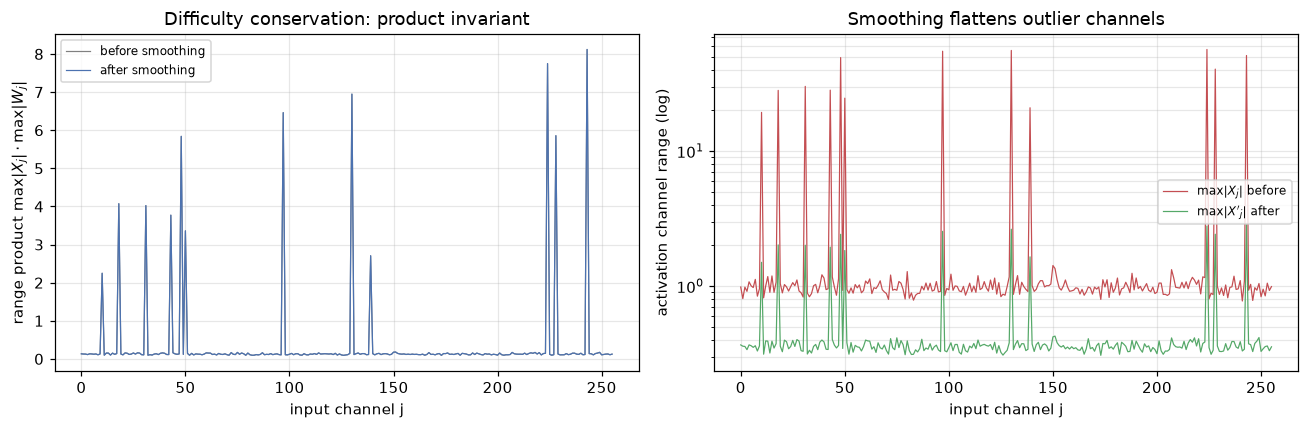

In [5]:
amax_x_before = np.max(np.abs(X), axis=0)
amax_w_before = np.max(np.abs(W), axis=1)
prod_before = amax_x_before * amax_w_before

X_smoothed = X / S_HALF
W_smoothed = W * S_HALF[:, None]
prod_after = np.max(np.abs(X_smoothed), axis=0) * np.max(np.abs(W_smoothed), axis=1)

consv_dev = float(np.max(np.abs(prod_after - prod_before) / prod_before))
print(f"per-channel range product: max rel deviation = {consv_dev:.2e}  (machine eps => conserved)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=110)
axes[0].plot(prod_before, lw=0.8, color="gray", label="before smoothing")
axes[0].plot(prod_after, lw=0.8, color="#4C72B0", label="after smoothing")
axes[0].set_xlabel("input channel j")
axes[0].set_ylabel(r"range product $\max|X_j| \cdot \max|W_j|$")
axes[0].set_title("Difficulty conservation: product invariant")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(amax_x_before, lw=0.8, color="#C44E52", label=r"$\max|X_j|$ before")
axes[1].plot(np.max(np.abs(X_smoothed), axis=0), lw=0.8, color="#55A868",
             label=r"$\max|X'_j|$ after")
axes[1].set_yscale("log")
axes[1].set_xlabel("input channel j")
axes[1].set_ylabel("activation channel range (log)")
axes[1].set_title("Smoothing flattens outlier channels")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 第 5 步 · α 扫描：激活/权重难度的「跷跷板」

**这步在做什么**：让 $\alpha$ 从 0 走到 1，记录每一档的层输出 MSE（左图，期望 U 形）与两侧的平均动态范围（右图，期望在 $\alpha \approx 0.5$ 交叉的跷跷板）：$\alpha \to 0$ 激活原样作恶，$\alpha \to 1$ 权重被放大受伤，谷底落在两端难度均衡处，即理论最优 $s_j^{*} = \sqrt{\max|X_j| / \max|W_j|}$。

alpha sweep:
  alpha = 0.00   MSE = 2.1846e-03
  alpha = 0.25   MSE = 3.9001e-04
  alpha = 0.50   MSE = 1.8346e-04
  alpha = 0.75   MSE = 3.3514e-04
  alpha = 1.00   MSE = 1.7609e-03
alpha* = 0.50   (theoretical balance point = 0.50)


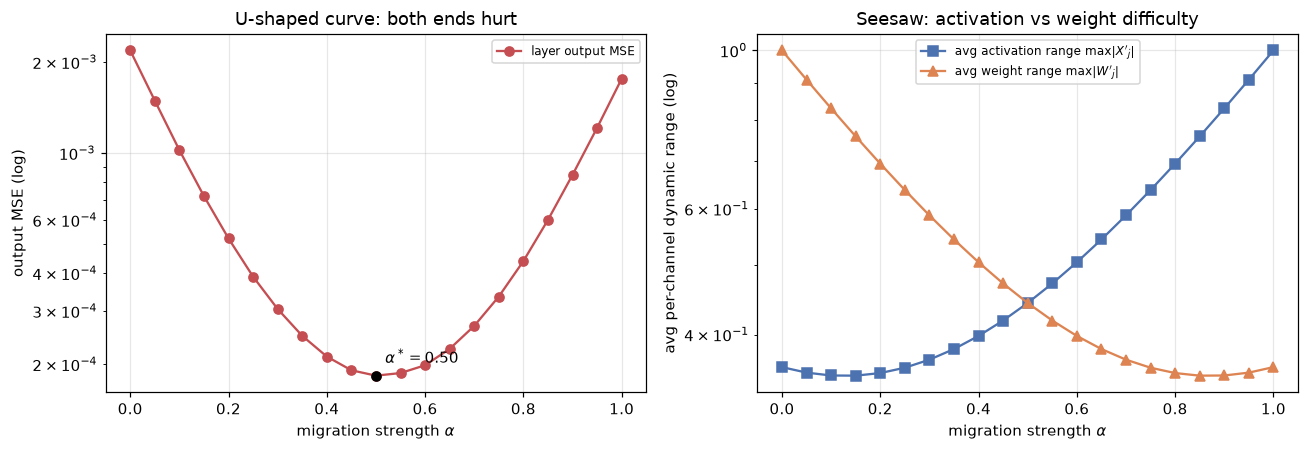

In [6]:
alphas = np.linspace(0.0, 1.0, 21)
mses, act_ranges, wgt_ranges = [], [], []
for a in alphas:
    sa = smooth_scale(X, W, a)
    mses.append(mse(w8a8_forward(X, W, s_vec=sa), Y_REF))
    act_ranges.append(float(np.mean(np.max(np.abs(X / sa), axis=0))))
    wgt_ranges.append(float(np.mean(np.max(np.abs(W * sa[:, None]), axis=1))))
mses = np.array(mses)
i_opt = int(np.argmin(mses))

print("alpha sweep:")
for a, m in zip(alphas, mses):
    if abs(a * 4 - round(a * 4)) < 1e-9:           # 每 0.25 打一档
        print(f"  alpha = {a:.2f}   MSE = {m:.4e}")
print(f"alpha* = {alphas[i_opt]:.2f}   (theoretical balance point = 0.50)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=110)
axes[0].plot(alphas, mses, "o-", color="#C44E52", label="layer output MSE")
axes[0].scatter([alphas[i_opt]], [mses[i_opt]], color="black", zorder=5, s=35)
axes[0].annotate(rf"$\alpha^* = {alphas[i_opt]:.2f}$", (alphas[i_opt], mses[i_opt]),
                 textcoords="offset points", xytext=(6, 8), fontsize=10)
axes[0].set_yscale("log")
axes[0].set_xlabel(r"migration strength $\alpha$")
axes[0].set_ylabel("output MSE (log)")
axes[0].set_title("U-shaped curve: both ends hurt")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(alphas, act_ranges, "s-", color="#4C72B0",
             label=r"avg activation range $\max|X'_j|$")
axes[1].plot(alphas, wgt_ranges, "^-", color="#DD8452",
             label=r"avg weight range $\max|W'_j|$")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"migration strength $\alpha$")
axes[1].set_ylabel("avg per-channel dynamic range (log)")
axes[1].set_title("Seesaw: activation vs weight difficulty")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 第 6 步 · 组合拳：per-token 激活 × 权重粒度（ZeroQuant 视角）

**这步在做什么**：固定激活侧为 per-token 动态量化，扫描权重侧粒度（per-tensor → group-wise g=128/64/32 → per-channel），分别在「不平滑」与「平滑」两种条件下对比——验证激活平滑与权重细粒度是两个正交、可叠加的自由度：前者解决主要矛盾，后者打磨残余误差。

In [7]:
configs = [
    ("per-tensor",       dict(weight_mode="per-tensor")),
    ("group-wise g=128", dict(weight_mode="group-wise", group=128)),
    ("group-wise g=64",  dict(weight_mode="group-wise", group=64)),
    ("group-wise g=32",  dict(weight_mode="group-wise", group=32)),
    ("per-channel",      dict(weight_mode="per-channel")),
]

print(f"{'weight granularity':<20s}{'no smooth':>12s}{'smooth a=0.5':>14s}")
for label, kw in configs:
    rels = []
    for s_vec in (None, S_HALF):
        Y = w8a8_forward(X, W, s_vec=s_vec, **kw)
        rels.append(rel_err(Y, Y_REF))
    print(f"{label:<20s}{rels[0]:>11.2%}{rels[1]:>14.2%}")

print("\nobserved: without smoothing the activation error dominates (granularity barely helps);")
print("after smoothing, finer weight granularity monotonically reduces error (diminishing returns).")

weight granularity     no smooth  smooth a=0.5
per-tensor                2.64%         1.22%
group-wise g=128          2.51%         0.87%
group-wise g=64           2.50%         0.82%
group-wise g=32           2.48%         0.77%
per-channel               2.52%         0.76%

observed: without smoothing the activation error dominates (granularity barely helps);
after smoothing, finer weight granularity monotonically reduces error (diminishing returns).


## 结果解读与方法局限

**真实运行数字（SEED = 0，可复现）**：

- **outlier 设定**：12 / 256（约 4.7%）的输入通道被放大，平均幅值约为中位通道的 **39 倍**；
- **直接 W8A8**：相对误差 **2.52%**（MSE 2.01e-3），正常值有效位宽被压到约 **3.3 bit**——scale 被少数 outlier 绑架，这正是博客 §1.3「有效精度坍塌」的微观形态；
- **SmoothQuant（α = 0.5）**：相对误差降到 **0.76%**（MSE 1.83e-4），MSE 改善 **10.9 倍**，正常值有效位宽从 3.3 恢复到约 **7.4 bit**；与本目录 `run.py` 更大规模（T = 1024）实测的「朴素 2.38% → 平滑 0.73%，改善 10.7 倍」完全同量级；
- **恒等式与守恒律**：不量化时 $\max|X'W' - XW| \approx 2.7 \times 10^{-15}$（浮点精度级别，说明平滑本身免费）；平滑前后每通道 range 乘积最大相对偏差 **2.6e-16**——难度守恒，平滑只是搬运而非消灭；
- **α 扫描**：MSE 呈标准 U 形——α = 0.00 时 2.18e-3，α = 0.25 时 3.90e-4，**α = 0.50 谷底 1.83e-4**，α = 0.75 回升至 3.35e-4，α = 1.00 时 1.76e-3；右图两条动态范围曲线恰好在 α ≈ 0.5 交叉，「此消彼长」一目了然，实测最优值正是理论均衡点 $s_j^{*} = \sqrt{\max|X_j| / \max|W_j|}$；
- **粒度组合拳**：不平滑时五种权重粒度的相对误差全部挤在 2.48%～2.64%（激活误差是主要矛盾）；平滑后权重粒度重新变得重要——per-tensor 1.22% → g = 128 的 0.87% → g = 64 的 0.82% → g = 32 的 0.77% → per-channel 0.76%，单调改善但收益递减，与博客中 ZeroQuant「group 64～128 收益最大、继续细化收益递减」的经验一致。

**方法局限**：

1. **校准集依赖**：$s_j$ 来自 $\max|X_{:,j}|$ 极值统计，线上分布一旦漂移（长尾生成、代码补全、多语言混排），静态平滑可能失效甚至帮倒忙；后续工作改用 99.9% 分位数换取稳健性，但会引入截断误差。
2. **α 是超参**：虽然论文报告 0.2～0.5 区间内不敏感，仍需网格搜索；本 demo 合成数据两侧近似对称才使 α* 恰为 0.50，真实模型各层最优 α 可能不同。
3. **静态假设**：outlier 幅值随生成内容波动，静态 $s$ 无法完全覆盖极端上下文；ZeroQuant 式 token-wise 动态 scale 对此免疫——今天的主流部署是两者的合流（静态平滑 + 动态 per-token scale）。
4. **toy 局限**：单层线性层加高斯噪声无法呈现逐层误差累积与下游任务退化（困惑度看不出、pass@k 看得出的那类损失），「8bit 无损」的结论不能直接外推到推理密集型任务。